In [56]:
import numpy as np

def Rz(Theta: float) -> np.ndarray:
    value = np.deg2rad(Theta)
    mat = np.eye(4)
    mat[:2, :2] = [[np.cos(value), -np.sin(value)],
                   [np.sin(value),  np.cos(value)]]
    return mat

def Rx(Theta: float) -> np.ndarray:
    value = np.deg2rad(Theta)
    mat = np.eye(4)
    mat[1:3, 1:3] = [[np.cos(value), -np.sin(value)],
                     [np.sin(value),  np.cos(value)]]
    return mat

def Tz(value: float) -> np.ndarray:
    mat = np.eye(4)
    mat[2, 3] = value
    return mat

def Tx(value: float) -> np.ndarray:
    mat = np.eye(4)
    mat[0, 3] = value
    return mat

def A(denavit_params: list) -> np.ndarray:
    Theta_z, L_z, Theta_x, L_x = denavit_params
    # Convenção: Translação seguida de Rotação
    return Tz(L_z) @ Rz(Theta_z) @ Tx(L_x) @ Rx(Theta_x)

In [57]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import clear_output
import time

def plot_frame_3d(T, ax, length, nome_junta=""):
    x0, y0, z0 = T[0, 3], T[1, 3], T[2, 3]
    x_dir, y_dir, z_dir = T[0:3, 0] * length, T[0:3, 1] * length, T[0:3, 2] * length
    ratio = 0.15
    
    ax.quiver(x0, y0, z0, x_dir[0], x_dir[1], x_dir[2], color='red', arrow_length_ratio=ratio)
    ax.quiver(x0, y0, z0, y_dir[0], y_dir[1], y_dir[2], color='green', arrow_length_ratio=ratio)
    ax.quiver(x0, y0, z0, z_dir[0], z_dir[1], z_dir[2], color='blue', arrow_length_ratio=ratio)
                     
    if nome_junta:
        offset = length * 0.3
        ax.text(x0 + offset, y0 + offset, z0 + offset, nome_junta, fontsize=5, fontweight='bold', 
                color='purple', zorder=5, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

def plot_manipulador_3d(listA: list, ax, axis_length: float = 1.0):
    T_acumulada = np.eye(4)
    xs, ys, zs = [0], [0], [0]

    plot_frame_3d(T_acumulada, ax, axis_length, nome_junta="Base")
    
    for i, A_i in enumerate(listA):
        T_acumulada = T_acumulada @ A_i
        x, y, z = T_acumulada[0, 3], T_acumulada[1, 3], T_acumulada[2, 3]
        xs.append(x); ys.append(y); zs.append(z)
        
        nome = "Efetuador" if i == len(listA) - 1 else f"Junta {i+1}"
        plot_frame_3d(T_acumulada, ax, axis_length, nome_junta=nome)
        
    ax.plot(xs, ys, zs, color='black', linewidth=4, marker='o', markersize=8, markerfacecolor='cyan', label='Elos')
    
    ax.set_xlabel('Eixo X'); ax.set_ylabel('Eixo Y'); ax.set_zlabel('Eixo Z')
    
    max_range = np.array([max(xs)-min(xs), max(ys)-min(ys), max(zs)-min(zs)]).max() / 2.0
    mid_x, mid_y, mid_z = (max(xs)+min(xs))*0.5, (max(ys)+min(ys))*0.5, (max(zs)+min(zs))*0.5
    padding = axis_length
    
    ax.set_xlim(mid_x - max_range - padding, mid_x + max_range + padding)
    ax.set_ylim(mid_y - max_range - padding, mid_y + max_range + padding)
    ax.set_zlim(mid_z - max_range - padding, mid_z + max_range + padding)
    
    elementos_legenda = [
        Line2D([0], [0], color='black', lw=4, marker='o', markerfacecolor='cyan', label='Elos'),
        Line2D([0], [0], color='red', lw=2, label='Eixo X'),
        Line2D([0], [0], color='green', lw=2, label='Eixo Y'),
        Line2D([0], [0], color='blue', lw=2, label='Eixo Z')
    ]
    ax.legend(handles=elementos_legenda, loc='upper left', fontsize=9)

# Robô planar

- 2 DoF rotacionais + junta prismática (RRP)

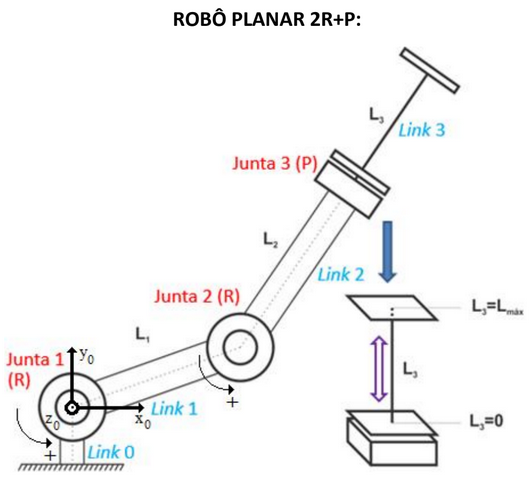

| $A_{i \to j}$ | $\Theta_z + \Theta_z^*$ | $L_z + L_z^*$ | $\Theta_x$ | $L_x$ |
| :--- | :---: | :---: | :---: | :---: |
| 0 $\to$ 1 | 0 | 0 | 0 | 0 |
| 1 $\to$ 2 | 30° + $\Theta^*$ | 0 | 0 | $L_1$ |
| 2 $\to$ 3 | 120° + $\Theta^*$ | 0 | 90° | 0 |
| 3 $\to$ 4 | 0 | $L_1 + L^*$ | 0 | 0 |

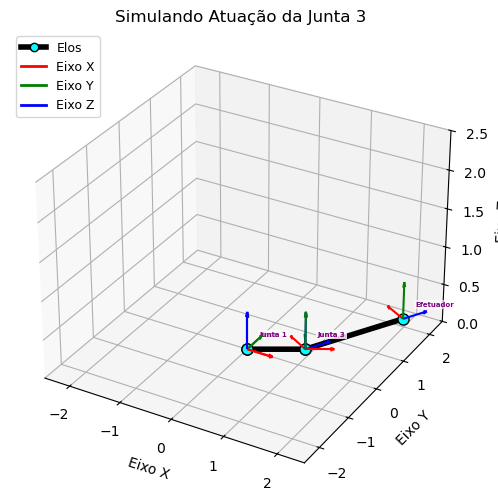

In [58]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

passos = 20
simulation = [
    np.linspace(0, 360, passos), # Simulação para Theta1
    np.linspace(0, 360, passos), # Simulação para Theta2
    np.linspace(0, 1, passos)    # Simulação para L3 (Prismática)
]

L = 1

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        Theta1 = val if junta == 0 else 0
        Theta2 = val if junta == 1 else 0
        L3 = val if junta == 2 else 0

        a01 = [0, 0, 0, 0] 
        a12 = [30 + Theta1, 0, 0, L]
        a23 = [120 + Theta2, 0, 90, 0]
        a34 = [0, L + L3, 0, 0]

        matrizes = [A(a01), A(a12), A(a23), A(a34)]

        plot_manipulador_3d(matrizes, ax, axis_length=0.5)
        
        limite = 2.5
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)

# Robô Articulado

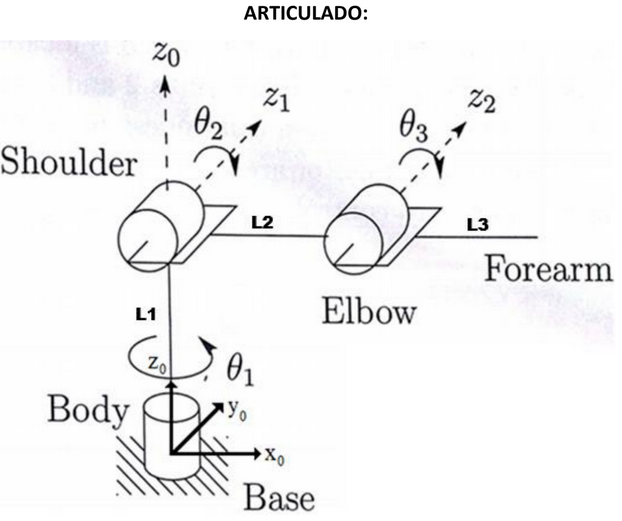




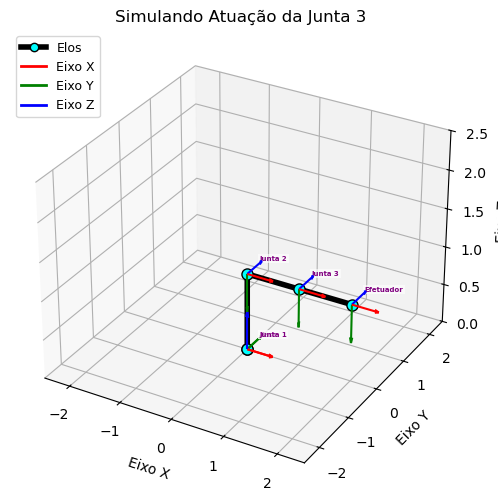

In [59]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

passos = 20
simulation = [
    np.linspace(0, 360, passos), # Simulação para Theta1
    np.linspace(0, 360, passos), # Simulação para Theta2
    np.linspace(0, 360, passos)  # Simulação para Theta3
]

L = 1

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        Theta1 = val if junta == 0 else 0
        Theta2 = val if junta == 1 else 0
        Theta3 = val if junta == 2 else 0

        a01 = [0, 0, 0, 0] 
        a12 = [Theta1, L, -90, 0] 
        a23 = [Theta2, 0, 0, L] 
        a34 = [Theta3, 0, 0, L] 

        matrizes = [A(a01), A(a12), A(a23), A(a34)]

        plot_manipulador_3d(matrizes, ax, axis_length=0.5)
        
        limite = 2.5
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)

# Cartesiano

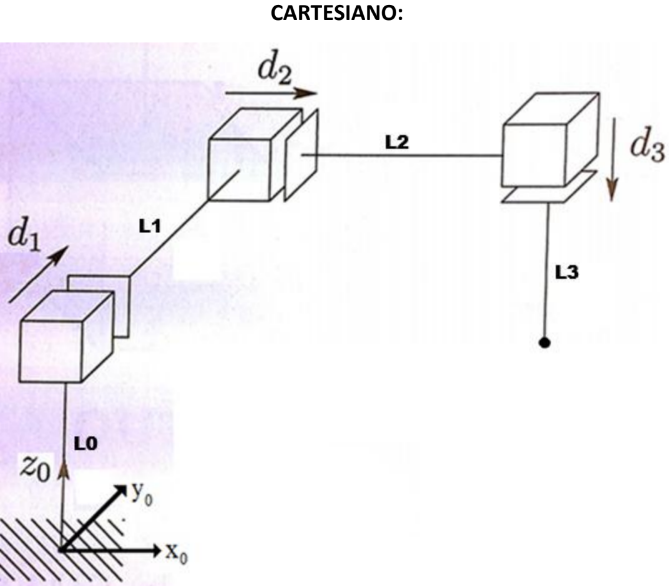

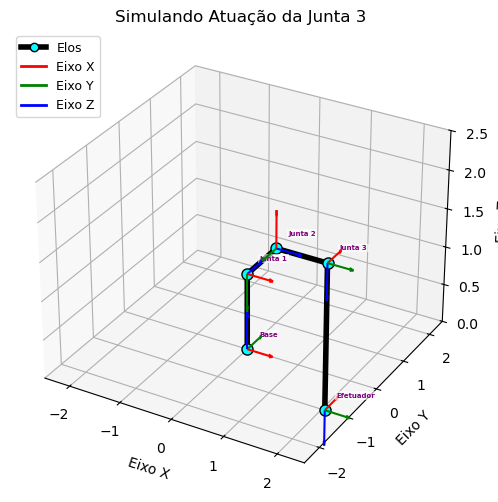

In [60]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

passos = 20
simulation = [
    np.linspace(0, 1, passos), # Simulação para d1
    np.linspace(0, 1, passos), # Simulação para d2
    np.linspace(0, 1, passos)  # Simulação para d3
]

L = 1

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        d1 = val if junta == 0 else 0
        d2 = val if junta == 1 else 0
        d3 = val if junta == 2 else 0

        a01 = [0, L, -90, 0] 
        a12 = [-90, L + d1, -90, 0] 
        a23 = [-90, L + d2, 90, 0] 
        a34 = [0, L + d3, 0, 0]

        matrizes = [A(a01), A(a12), A(a23), A(a34)]

        plot_manipulador_3d(matrizes, ax, axis_length=0.5)
        
        limite = 2.5
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)

# Robô esférico

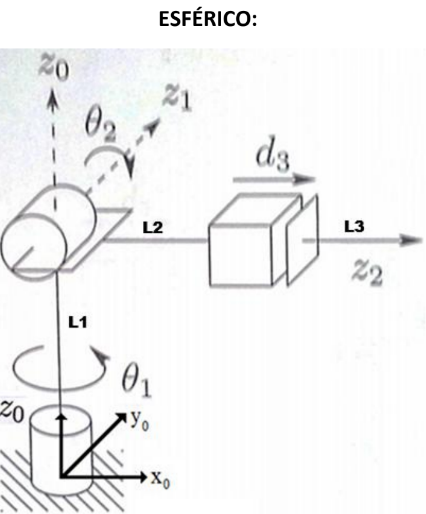

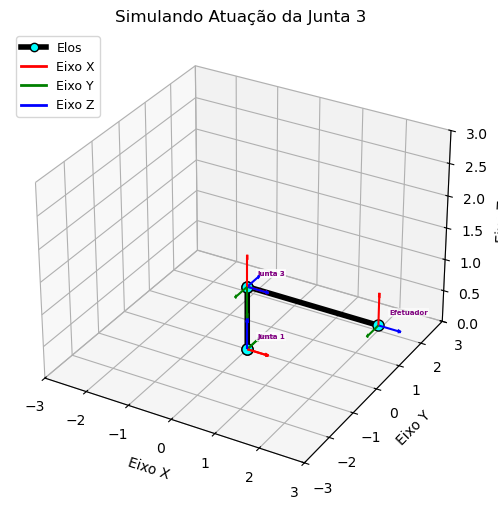

In [61]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

passos = 20
simulation = [
    np.linspace(0, 360, passos), # Simulação para Theta1
    np.linspace(0, 360, passos), # Simulação para Theta2
    np.linspace(0, 1, passos)    # Simulação para d3
]

L = 1

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        Theta1 = val if junta == 0 else 0
        Theta2 = val if junta == 1 else 0
        d3 = val if junta == 2 else 0

        a01 = [Theta1, 0, 0, 0] 
        a12 = [0, L, -90, 0] 
        a23 = [-90 + Theta2, 0, -90, 0] 
        a34 = [0, 2 * L + d3, 0, 0] 

        matrizes = [A(a01), A(a12), A(a23), A(a34)]

        plot_manipulador_3d(matrizes, ax, axis_length=0.5)
        
        limite = 3.0
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)

# Robô Cilindrico

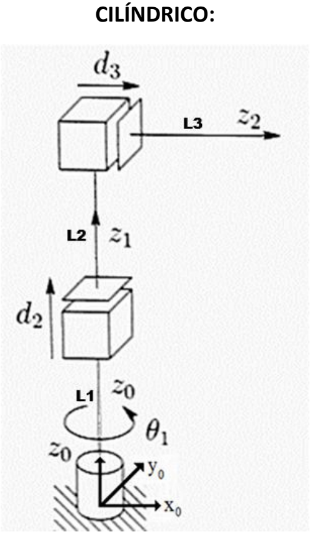

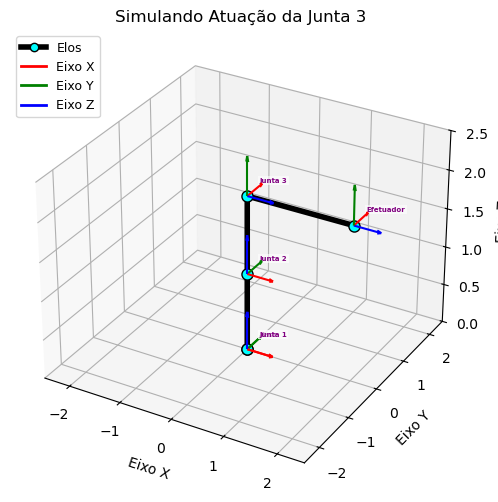

In [62]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

passos = 20
simulation = [
    np.linspace(0, 360, passos), # Simulação para Theta1
    np.linspace(0, 1, passos),   # Simulação para d2
    np.linspace(0, 1, passos)    # Simulação para d3
]

L = 1

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        Theta1 = val if junta == 0 else 0
        d2 = val if junta == 1 else 0
        d3 = val if junta == 2 else 0

        a01 = [Theta1, 0, 0, 0] 
        a12 = [0, L, 0, 0] 
        a23 = [90, L + d2, 90, 0] 
        a34 = [0, L + d3, 0, 0] 

        matrizes = [A(a01), A(a12), A(a23), A(a34)]

        plot_manipulador_3d(matrizes, ax, axis_length=0.5)
        
        limite = 2.5
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)

# Robô SCARA

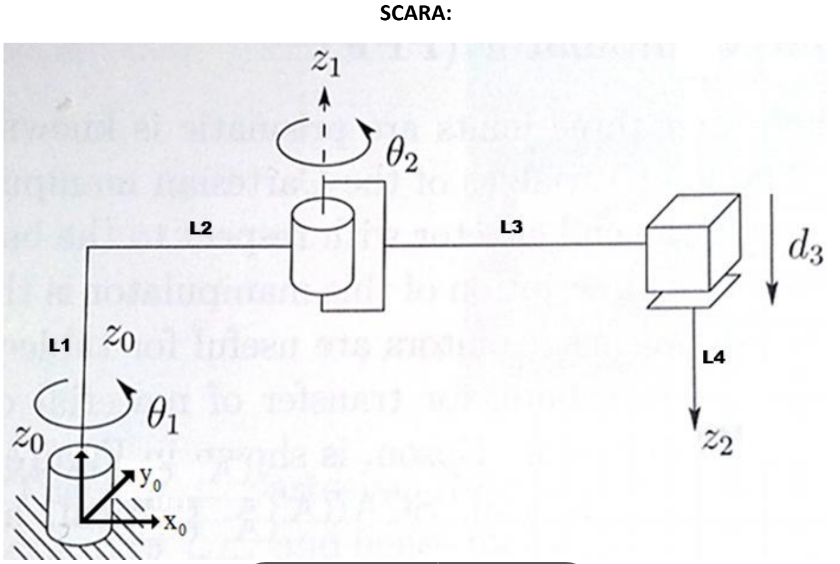

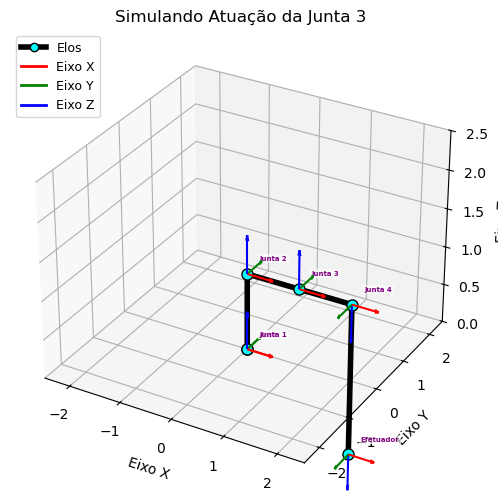

In [63]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

passos = 20
simulation = [
    np.linspace(0, 360, passos), # Simulação para Theta1
    np.linspace(0, 360, passos), # Simulação para Theta2
    np.linspace(0, 1, passos)    # Simulação para d3
]

L = 1

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        Theta1 = val if junta == 0 else 0
        Theta2 = val if junta == 1 else 0
        d3 = val if junta == 2 else 0

        a01 = [Theta1, 0, 0, 0] 
        a12 = [0, L, 0, 0] 
        a23 = [0, 0, 0, L]
        a34 = [Theta2, 0, 180, L] 
        a45 = [0, L + d3, 0, 0] 

        matrizes = [A(a01), A(a12), A(a23), A(a34), A(a45)]

        plot_manipulador_3d(matrizes, ax, axis_length=0.5)
        
        limite = 2.5
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)

# SCHUNK 7DOF:

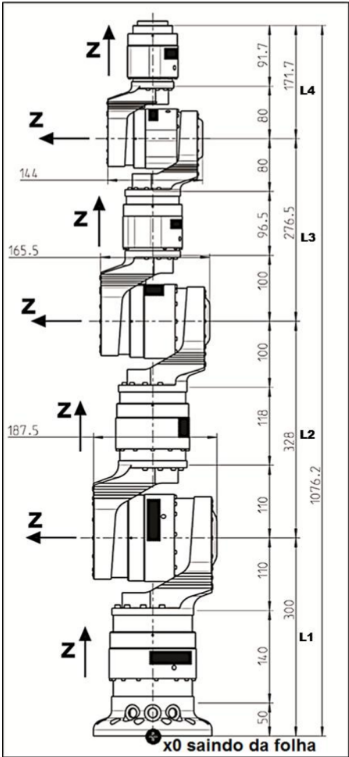

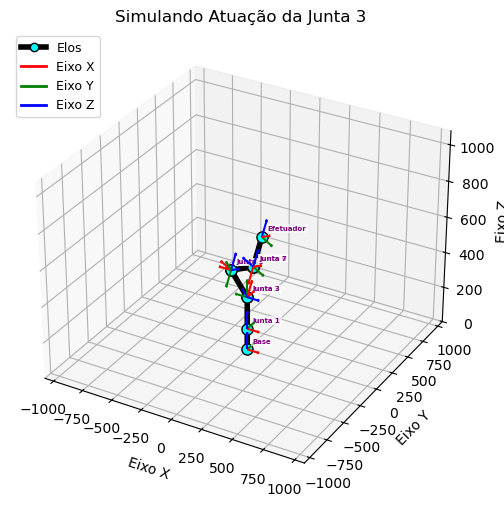

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

L1 = 50 + 140/2
L2 = 140/2 + 110
L3 = 110 + 118/2
L4 = 118/2 + 100
L5 = 100 + 96.5/2
L6 = 96.5/2 + 80
L7 = 80 + 91.7/2
L8 = 91.7/2
L = L1+L2+L3+L4+L5+L6+L7+L8

passos = 20
simulation = [
    np.linspace(0, 360, passos), # Simulação para Theta1
    np.linspace(0, 360, passos), # Simulação para Theta2
    np.linspace(0, 360, passos),    # Simulação para d3
    np.linspace(0, 360, passos),    # Simulação para d3
    np.linspace(0, 360, passos),    # Simulação para d3
    np.linspace(0, 360, passos),    # Simulação para d3
    np.linspace(0, 360, passos),    # Simulação para d3
]

for junta, sim_values in enumerate(simulation):
    for val in sim_values:
        ax.clear()
        
        Theta1 = val if junta == 0 else 0
        Theta2 = val if junta == 1 else 0
        Theta3 = val if junta == 2 else 0
        Theta4 = val if junta == 3 else 0
        Theta5 = val if junta == 4 else 0
        Theta6 = val if junta == 5 else 0
        Theta7 = val if junta == 6 else 0
        d3 = val if junta == 2 else 0
        #        Rz   Tz  Rx  Tx
        a01 = [0, L1, 0, 0] 
        a12 = [Theta1, L2, 90, 0] 
        a23 = [Theta2, 0, -90 ,0]
        a34 = [Theta3, L3 + L4, 90, 0] 
        a45 = [Theta4, 0, -90, 0] 
        a56 = [Theta5, L5 + L6, 90, 0] 
        a67 = [Theta6, 0, -90, 0] 
        a78 = [Theta7, L7 + L8, 0, 0] 

        matrizes = [A(a01), A(a12), A(a23), A(a34), A(a45), A(a56), A(a67), A(a78)]

        plot_manipulador_3d(matrizes, ax, axis_length=100)
        
        limite = L
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(0, limite)
        
        ax.set_title(f"Simulando Atuação da Junta {junta + 1}")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.05)
plt.close(fig)